In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("==================================================")
print(" PHASE 3: EXPLORATORY DATA ANALYSIS (EDA)")
print("==================================================")

# 1. Load the cleaned dataset
try:
    df = pd.read_csv('Clean.csv')
    print("Clean.csv loaded successfully!\n")
except FileNotFoundError:
    print("Error: Clean.csv not found. Please run the cleaning script first.")
    exit()

# Set professional visual style
sns.set_theme(style="whitegrid", palette="muted")

# ==========================================
# 1. SUMMARY STATISTICS (Mean, Median, Spread)
# ==========================================
print("--- Summary Statistics ---")
summary_stats = df[['Price_GBP', 'Rating_Num', 'Stock_Quantity']].describe().round(2)
print(summary_stats)

 PHASE 3: EXPLORATORY DATA ANALYSIS (EDA)
Clean.csv loaded successfully!

--- Summary Statistics ---
       Price_GBP  Rating_Num  Stock_Quantity
count     999.00      999.00          999.00
mean       35.07        2.92           12.98
std        14.45        1.43            7.44
min        10.00        1.00            1.00
25%        22.10        2.00            6.00
50%        36.00        3.00           13.00
75%        47.47        4.00           19.00
max        59.99        5.00           25.00


In [11]:
# CRITICAL FIXES: Force these columns to be numeric so we can do math on them
df['Price_GBP'] = pd.to_numeric(df['Price_GBP'], errors='coerce')
df['Stock_Quantity'] = pd.to_numeric(df['Stock_Quantity'], errors='coerce')

print("\n--- Trend Analysis ---")
rating_price_trend = df.groupby('Rating_Num')['Price_GBP'].mean().round(2)
print("Average Price by Star Rating:\n", rating_price_trend)

stock_price_trend = df.groupby('Price_Band')['Stock_Quantity'].mean().round(2)
print("\nAverage Stock Quantity by Price Band:\n", stock_price_trend)


--- Trend Analysis ---
Average Price by Star Rating:
 Rating_Num
1    34.56
2    34.81
3    34.69
4    36.09
5    35.39
Name: Price_GBP, dtype: float64

Average Stock Quantity by Price Band:
 Price_Band
Budget      13.15
Premium     13.19
Standard    12.61
Name: Stock_Quantity, dtype: float64



Generating Visualizations...


C:\Users\91787\AppData\Local\Temp\ipykernel_13532\2357499909.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Rating_Num', y='Price_GBP', palette='viridis', errorbar=None)


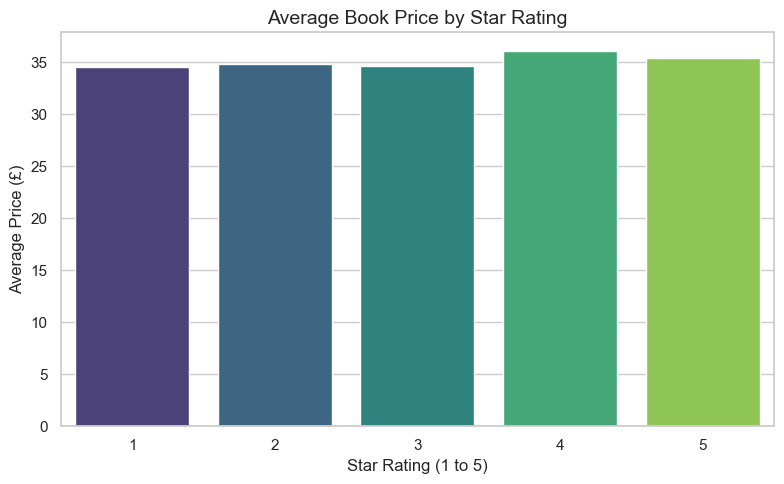

In [16]:
# ==========================================
# 3. VISUALIZATIONS
# ==========================================
print("\nGenerating Visualizations...")

# A. Bar Chart: Average Price by Rating
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Rating_Num', y='Price_GBP', palette='viridis', errorbar=None)
plt.title('Average Book Price by Star Rating', fontsize=14)
plt.xlabel('Star Rating (1 to 5)')
plt.ylabel('Average Price (£)')
plt.tight_layout()
plt.show()

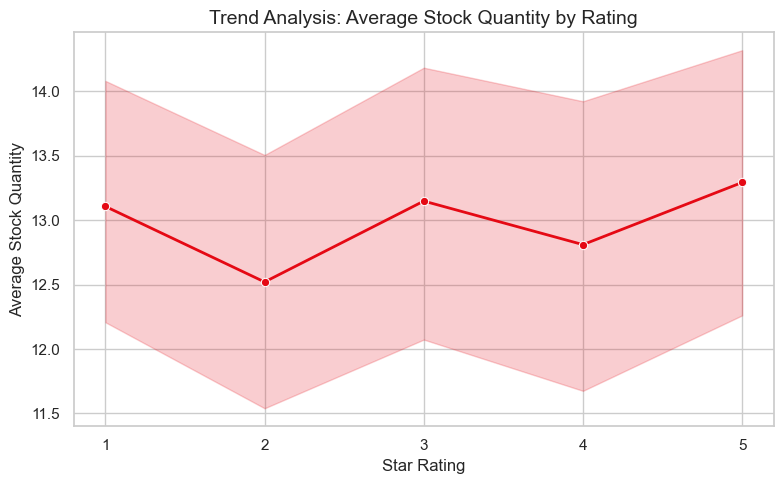

In [15]:
# B. Line Chart: Trend of Stock Quantity across Ratings
plt.figure(figsize=(8, 5))
sns.lineplot(data=df, x='Rating_Num', y='Stock_Quantity', marker='o', color='#E50914', linewidth=2)
plt.title('Trend Analysis: Average Stock Quantity by Rating', fontsize=14)
plt.xlabel('Star Rating')
plt.ylabel('Average Stock Quantity')
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show()

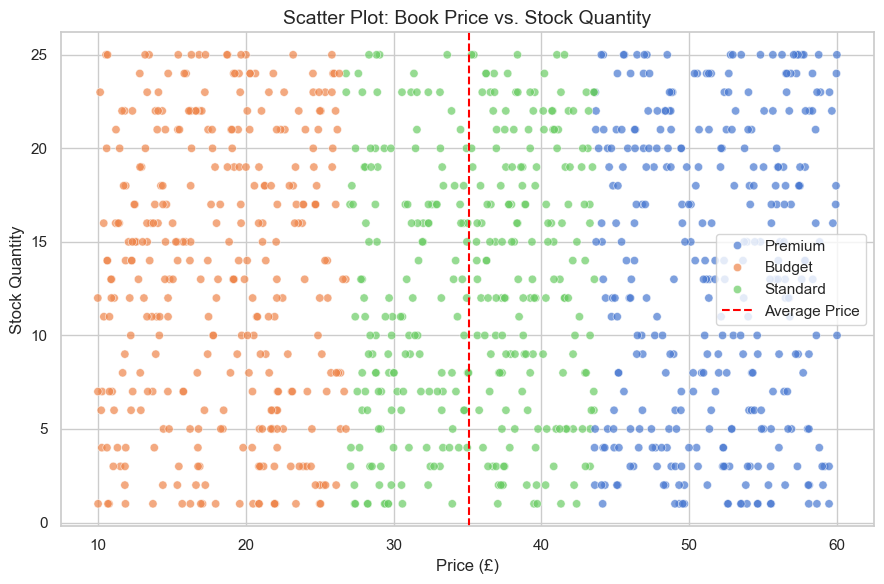

In [14]:
# C. Scatter Plot: Price vs. Stock Quantity
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='Price_GBP', y='Stock_Quantity', hue='Price_Band', alpha=0.7)
plt.title('Scatter Plot: Book Price vs. Stock Quantity', fontsize=14)
plt.xlabel('Price (£)')
plt.ylabel('Stock Quantity')
plt.axvline(df['Price_GBP'].mean(), color='red', linestyle='--', label='Average Price')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\91787\AppData\Local\Temp\ipykernel_13532\2688933897.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Rating_Num', y='Price_GBP', palette='Set2')


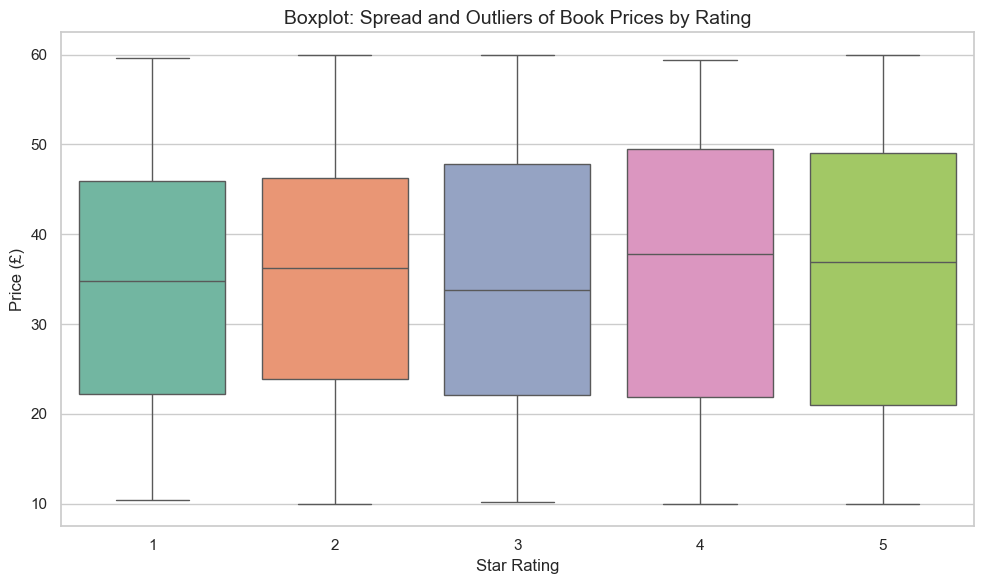

In [13]:
# D. Boxplots: Spread and Outliers of Prices by Rating
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Rating_Num', y='Price_GBP', palette='Set2')
plt.title('Boxplot: Spread and Outliers of Book Prices by Rating', fontsize=14)
plt.xlabel('Star Rating')
plt.ylabel('Price (£)')
plt.tight_layout()
plt.show()

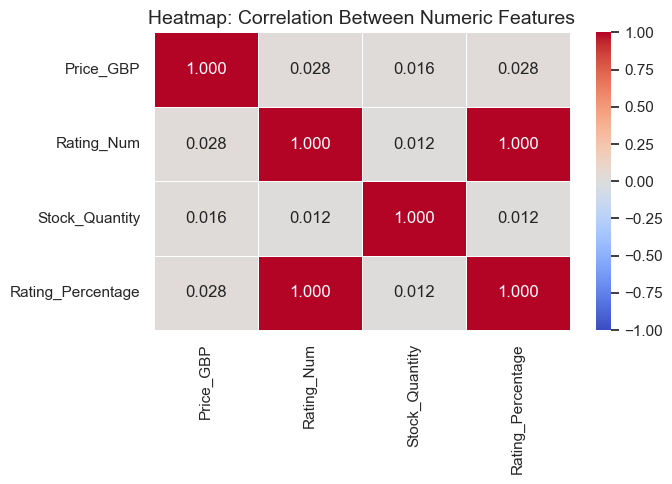

In [12]:
# E. Heatmap: Feature Correlations
plt.figure(figsize=(7, 5))
numeric_cols = df[['Price_GBP', 'Rating_Num', 'Stock_Quantity', 'Rating_Percentage']]
corr_matrix = numeric_cols.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Heatmap: Correlation Between Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()